In [1]:
from google.colab import files
uploaded = files.upload()

Saving car.csv to car.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [3]:
df = pd.read_csv("car.csv")

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.shape

(301, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [8]:
df["Car_Age"] = 2026 - df["Year"]
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [9]:
df.drop("Year", axis=1, inplace=True)
df.head()

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Car_Name"] = le.fit_transform(df["Car_Name"])
df["Fuel_Type"] = le.fit_transform(df["Fuel_Type"])
df["Seller_Type"] = le.fit_transform(df["Seller_Type"])
df["Transmission"] = le.fit_transform(df["Transmission"])

df.head()

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,90,3.35,5.59,27000,2,0,1,0,12
1,93,4.75,9.54,43000,1,0,1,0,13
2,68,7.25,9.85,6900,2,0,1,0,9
3,96,2.85,4.15,5200,2,0,1,0,15
4,92,4.60,6.87,42450,1,0,1,0,12


In [11]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(240, 8)
(61, 8)


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()

lr.fit(X_train, y_train)

prediction = lr.predict(X_test)

print("Accuracy (R2 Score):", r2_score(y_test, prediction))

Accuracy (R2 Score): 0.846553966686395


In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_prediction = rf.predict(X_test)

print("Random Forest Accuracy:", r2_score(y_test, rf_prediction))

Random Forest Accuracy: 0.9644787927030857


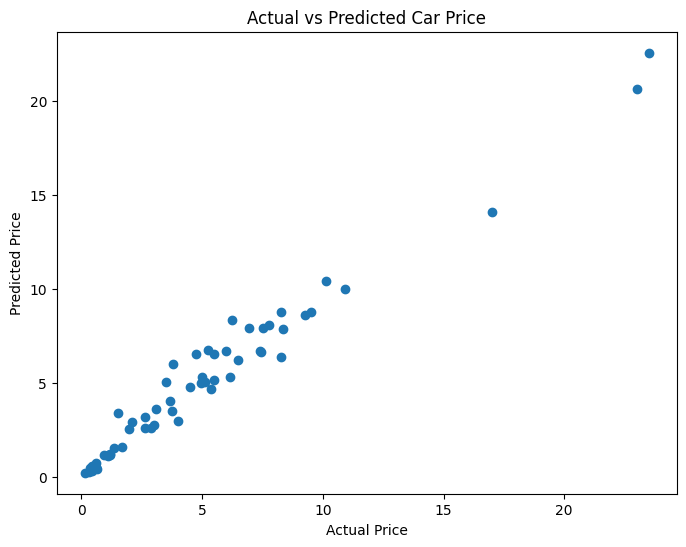

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_prediction)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")

plt.show()

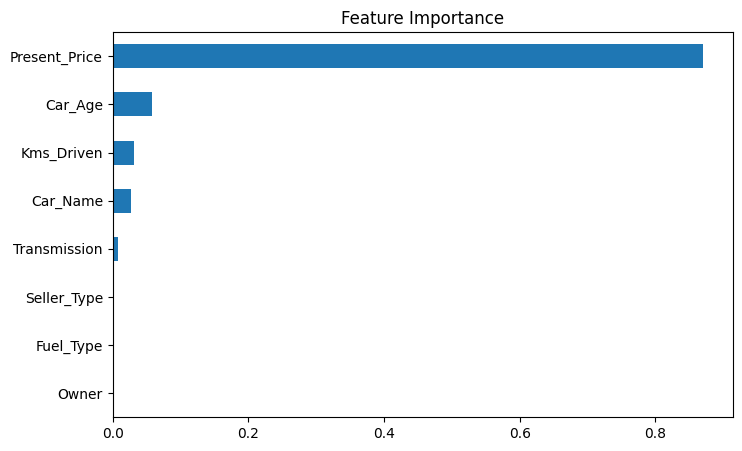

In [16]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh", figsize=(8,5))

plt.title("Feature Importance")
plt.show()

In [17]:
import pickle

pickle.dump(rf, open("car_price_model.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully
